In [1]:
import torch
from torch import nn
import torch_geometric
from torch_geometric.nn import SAGEConv, GraphConv, GraphSAGE
import torch
import networkx as nx 
from torch.utils.data import Dataset, DataLoader
import pickle
import pdb 
import numpy as np
from torch_geometric.data import Data
import networkx as nx
import numpy as np
import pandas as pd 
import pickle
import pdb
from torch_geometric.loader import DataLoader
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj, subgraph, k_hop_subgraph
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'tools'))
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'sim'))
from sklearn.neighbors import kneighbors_graph
from torch.optim.lr_scheduler import ReduceLROnPlateau
from ClassGraphDat import GraphDataset
torch.manual_seed(42)

In [2]:
class GraphEncoderWithResidual(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GraphEncoderWithResidual, self).__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels*4)
        self.conv2 = SAGEConv(hidden_channels*4, hidden_channels*2)
        self.conv3 = SAGEConv(hidden_channels*2, hidden_channels)
        self.lin = nn.Linear(hidden_channels, out_channels)
        # Linear transformation to match dimensions for residual connection
        self.shortcut = nn.Linear(in_channels, out_channels)
        # self.sm = nn.Softmax(dim=1)

    def forward(self, x, edge_index):
        identity = x
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = self.conv3(x, edge_index)
        x = self.lin(x)
        # Applying shortcut and adding it to the output of conv3
        identity = self.shortcut(identity)
        x += identity  # Element-wise addition
        # x = self.sm(x)
        return x

In [3]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)  # Prevents nans when the loss is zero
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        return torch.mean(F_loss)

focal_loss = FocalLoss(alpha=0.25, gamma=2.0)

# Assuming a loss function appropriate for node feature reconstruction, e.g., MSE for continuous features
def loss_function(reconstructed_x, original_x):

    # print(/)
    # bce_loss_fn = torch.nn.BCEWithLogitsLoss()
    # loss = bce_loss_fn(logits, one_hot_targets)
    # [  2204787.0/14022   ,2204787.0/35079,  2204787.0/780448 ,2204787.0/1375238]
    # weights = torch.tensor([ 662843/17722.0,  662843/49808.0, 662843/209018.0, 662843/386295.0], dtype=torch.float)
    weights = torch.tensor([  2204787.0/14022   ,2204787.0/35079,  2204787.0/780448 ,2204787.0/1375238], dtype=torch.float)
    weights = weights/torch.sum(weights)
    # return F.cross_entropy(reconstructed_x, original_x, weight=weights, label_smoothing=0.2)
    # return F.cross_entropy(reconstructed_x, original_x, label_smoothing=0.4)
    return F.cross_entropy(reconstructed_x, original_x)#/scale#, label_smoothing=0.4)   

# bce_loss_fn = torch.nn.BCEWithLogitsLoss()
# loss = bce_loss_fn(logits, one_hot_targets)
# print(loss) 

def cosine_loss(adj, emb):
    norms = torch.norm(emb, p=2, dim=1, keepdim=True)
    normalized_embeddings = emb / norms.clamp(min=1e-4)
    cosine_similarity_matrix = torch.mm(normalized_embeddings, normalized_embeddings.t())
    target_adjacency = torch.zeros_like(cosine_similarity_matrix)
    target_adjacency[adj[0], adj[1]] = 1
    # Directly using logits; no need to apply sigmoid.
    return F.binary_cross_entropy_with_logits(cosine_similarity_matrix, target_adjacency)

In [4]:
def train(model, data_loader, optimizer, device):
    model.train()
    total_loss = 0
    embeddings = []
    origs = []
    # lossfunc = nn.CrossEntropyLoss()
    # print(data_loader)
    printlosses = []
    for data in data_loader:
        optimizer.zero_grad()
        # print(np.shape(data[0][0]), np.shape(data[1][0]), np.shape(data[2][0]))
        embed = model(data[0][0].to(device), data[1][0].to(device))
        # print(len(data[0][0]))
        loss = loss_function(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
        # loss = focal_loss(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
        loss.backward()
        optimizer.step()
        total_loss += loss.detach().item()
        printlosses.append(loss.detach().item())
        if len(printlosses)%10000 == 0:
            printlosses = printlosses[-10000:]
            print(np.sum(printlosses)/10000.0)
        # embeddings.append(embed.detach())
        # print(total_loss)/10.0
    return total_loss / len(data_loader), embeddings, origs

In [5]:
folder_graph = './finished_0p5/'
device = "cpu"
# fname = 'small_graphs.pth'
files = os.listdir(folder_graph)
files = [file for file in files if file.endswith('.pickle')]
hC = 60
inC = 40

dataset = GraphDataset(folder_graph, files)

dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=8)
actuals = []
final_loss = []
embeddings = []
outchannels = 4
model = GraphEncoderWithResidual(in_channels=inC, hidden_channels=hC, out_channels=outchannels).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
# scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True)
losses = []
embeds = []
acts = []
for epoch in range(1, 3):  # Number of epochs
    loss, embed, orig = train(model, dataloader, optimizer, device)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
    # scheduler.step(loss)
# epoch_loss = loss / len(dataloader)
# embeddings.append(embeds)
# final_loss.append(losses)
# actuals.append(acts)

# Assuming encoder and decoder are your model's components
encoder_state_dict = model.state_dict()
# decoder_state_dict = model.decoder.state_dict()
# Save the state dictionaries
torch.save(encoder_state_dict, './0p5FinishedLinClass_encoder_state_dict'+str(outchannels)+'.pth')
# torch.save(decoder_state_dict, './CDC/decoder_state_dict'+str(outchannels)+'.pth')
        # print(np.shape(embed), np.shape(data[2][0]), np.shape(data[0][0]), np.shape(data[1][0]))


1.1110933479207334
1.0682931150698103
1.0703327535503544
1.0800341269853524
1.0713092046672479
1.0722925537652568
1.0638173259299248
1.0671995968505275
1.0707695893326774
Epoch 1, Loss: 1.0750
1.0732508488973602
1.0647239675795659
1.0684611634301022
1.069865882208012
1.0741522223268636
1.0744399587079883
1.0650735779370182
1.0674578828416765
1.0611041686650367
Epoch 2, Loss: 1.0686


In [6]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(1, 3):  # Number of epochs
    loss, embed, orig = train(model, dataloader, optimizer, device)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)

encoder_state_dict = model.state_dict()
torch.save(encoder_state_dict, './0p5FinishedLinClass_encoder_state_dict'+str(outchannels)+'.pth')


1.0072195936549455
1.007208294356242
1.002099433996901
0.9981757128693164
0.9970718004506082
1.0034609138239174
0.9878513017639518
0.9945853890426457
0.9972469688788056
Epoch 1, Loss: 0.9995
0.997732277119346
0.9893133919436484
0.9985086852593348
1.0035536767080426
1.0041595431949943
0.995321797469072
0.9955508044339716
1.000369935685955
1.0076322535343467
Epoch 2, Loss: 0.9990


In [7]:
optimizer = optim.Adam(model.parameters(), lr=0.0001)

for epoch in range(1, 3):  # Number of epochs
    loss, embed, orig = train(model, dataloader, optimizer, device)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)

encoder_state_dict = model.state_dict()
torch.save(encoder_state_dict, './0p5FinishedLinClass_encoder_state_dict'+str(outchannels)+'.pth')

0.9947884182341397
0.9933543201349676
0.9933763337254524
0.9886198291357606
0.9839013785667717
0.9938841756854206
0.9965588198658079
0.9867974643919617
1.0016366590451449
Epoch 1, Loss: 0.9926
0.992065392620489
1.0063343687132
0.990694769147411
0.9914278786338866
0.975865788353607
0.9877362192291766
0.9950949670232833
0.9935946019846946
1.0002099599253387
Epoch 2, Loss: 0.9924


In [8]:
# sf = nn.Softmax(dim=1)
# x = torch.tensor([[-0.5207, -0.6732,  0.1790, -0.5166], [-0.3699, -0.7055, -0.0155, -0.2880]])
# print(np.shape(x))
# print(sf(x))

In [9]:
from params import ENVIRONMENT_BOUNDARY_X, COMMIT_THRESHOLD
from sklearn.neighbors import kneighbors_graph
from scipy.spatial import ConvexHull
MAX_DIST=ENVIRONMENT_BOUNDARY_X[-1]

torch.manual_seed(42)

STATES_LIST = ['RECRUIT', 'ASSESS', 'TRAVEL_HOME_TO_RECRUIT', 'TRAVEL_SITE', 'OBSERVE', 'EXPLORE', 'TRAVEL_HOME_TO_OBSERVE']
STATES = {'RECRUIT':0.0/6.0, 'ASSESS':1.0/6.0, 'TRAVEL_HOME_TO_RECRUIT':2.0/6.0, 'TRAVEL_SITE':3.0/6.0, 
          'OBSERVE':4.0/6.0, 'EXPLORE':5.0/6.0, 'TRAVEL_HOME_TO_OBSERVE':6.0/6.0}


folder_graph = './finished_0p5/'
files = os.listdir(folder_graph)
files = [file for file in files if file.endswith('.pickle')]
arr = dict()
arr1 = []
arrpos = []
arrqual = []
arrcol = []
arrclass = []
arr_global_info = []
arr_num_agents = []
# metadata = pd.read_csv('./graphsage_results/CDC/multiple_agent_env_results/metadata.csv')
for file in files[:-1]:
    fil =  open(folder_graph+file, 'rb')
    G = pickle.load(fil)
    fil.close()
    # pdb.set_trace()
    nA = file.split(')')[-1][:2]
    if nA[-1] == '_':
        num_agents = int(file.split(')')[-1][0])
    else:
        num_agents = int(file.split(')')[-1][:2])

    for node in G.nodes(data=True):
        # pdb.set_trace()
        if node[1]['x'] in arr:
        # if tuple(oneHotToState(node[1]['x'])) in arr:
            continue
        else:
            # pdb.set_trace()
            # new_color = get_color(node[1]['x'], node[1]['quals'])
            # arrpos.append(get_complete_poses(node[1]['poses']))
            # arrqual.append(get_complete_quals(node[1]['quals']))
            # arrcol.append(new_color)
            # arr_global_info.append(get_complete_global(node[1]['global_info']))
            # arr_num_agents.append(num_agents)
            # arr2.append([node[0], node[1]['x'], node[1]['colors'], node[1]['quals'], node[1]['poses'], node[1]['global_info'], num_agents])
            # pdb.set_trace()
            arrclass.append(list(node[1]['classes']))
            arr1.append(node[1]['x'])#+list(node[1]['global_info']))
            # arr1.append(list(node[1]['x'])+list(node[1]['global_info']))
             # arr.append([list(node[1]['x'])+[a for a in node[1]['global_info']]])
            # arr[tuple(oneHotToState(node[1]['x']))] = node[1]['colors']  
            arr[node[1]['x']] = node[1]['colors']  

encoder_dict = torch.load('./0p5FinishedLinClass_encoder_state_dict4.pth')
in_channels = 40
hidden_channels = 60
out_channels = 4
GAE = GraphEncoderWithResidual(in_channels, hidden_channels, out_channels)
GAE.load_state_dict(encoder_dict)
emb = []
arrtosave = []
# for i in arr1: 
for i in arr1: 
    # pdb.set_trace()
    emb.append(GAE(torch.tensor([i], dtype=torch.float), torch.empty((2,0), dtype=torch.int64)).detach().tolist()[0])
    arrtosave.append(i) 



In [10]:
print(np.shape(arrclass), np.shape(emb))

y_true_indices = np.argmax(arrclass, axis=1)
y_pred_indices = np.argmax(emb, axis=1)
# print(np.argmax(emb, axis=1)[0:10])
# print(np.argmax(arrclass, axis=1)[0:10])


(2204689, 4) (2204689, 4)


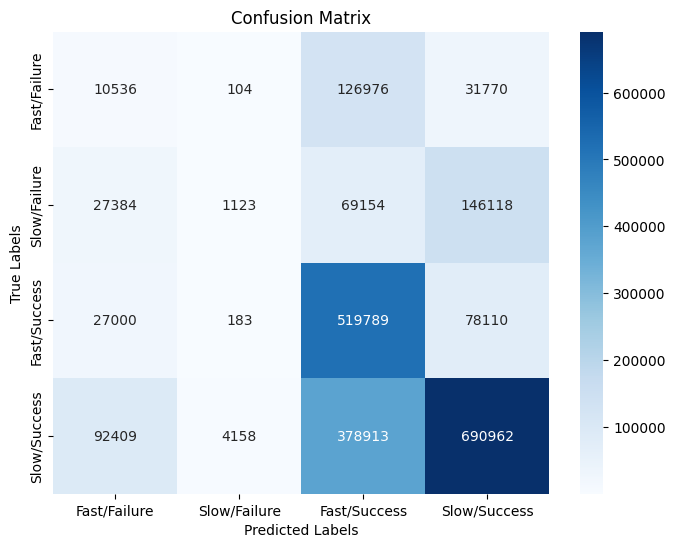

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
cm = confusion_matrix(y_true_indices, y_pred_indices)
# ConfusionMatrixDisplay(cm).plot()
CLIST =  ["Fast/Failure", "Slow/Failure", "Fast/Success", "Slow/Success"]
# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=CLIST, yticklabels=CLIST)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()
# 

In [12]:
# print(np.sum([1 for y in y_true_indices if y == 1]))
total = np.sum(cm, axis=1)
print(total, np.sum(total))
print(cm)
# 0: 14022, 1: 35079, 2: 780448 1375238

[ 169386  243779  625082 1166442] 2204689
[[ 10536    104 126976  31770]
 [ 27384   1123  69154 146118]
 [ 27000    183 519789  78110]
 [ 92409   4158 378913 690962]]


In [13]:
# STATES_LIST = ['RECRUIT', 'ASSESS', 'TRAVEL_HOME_TO_RECRUIT', 'TRAVEL_SITE', 'OBSERVE', 'EXPLORE', 'TRAVEL_HOME_TO_OBSERVE']
# STATES = {'RECRUIT':0.0/6.0, 'ASSESS':1.0/6.0, 'TRAVEL_HOME_TO_RECRUIT':2.0/6.0, 'TRAVEL_SITE':3.0/6.0, 
#           'OBSERVE':4.0/6.0, 'EXPLORE':5.0/6.0, 'TRAVEL_HOME_TO_OBSERVE':6.0/6.0}

# folder_graph = './classGraphs/'
# files = os.listdir(folder_graph)
# files = [file for file in files if file.endswith('.pickle')]
# file = files[0]
# # for file in files[:-1]:
# fil =  open(folder_graph+file, 'rb')
# G = pickle.load(fil)
# fil.close()

# newx = []
# i=0
# while i < 10:
#     st = G.nodes[100]['x']
#     state = np.round(STATES[STATES_LIST[st[10*i:10*i+7].index(1)]], 3)
#     # print(STATES[state], G.nodes[0]['x'][10*i:10*i+7])
#     newx.append(state)
#     for j in range(10*i+7, 10*i+10):
#         newx.append(st[j])
#     i += 1
# print(st)
# print(newx)
